# 🏥 Hospital Readmission Prediction
## **Overview**
This dataset helps predict which patients are at **high risk of readmission within 30 days of discharge**.  
It mimics real-world patterns to support healthcare strategies and **reduce preventable readmissions**,  
which cost hospitals an estimated **$17 billion annually**.

### **Dataset Details**
- **Size:** 30,000 patient records
- **Features:** 11 clinical & demographic variables
- **Target:** `readmitted_30_days` (Binary: **Yes/No**)

---

## **📂 Files Included**
| File Name | Description |
|-----------|------------|
| **`hospital_readmissions_30k.csv`** | Main dataset containing patient records |
| **`sample_submission.csv`** | Example submission file for competitions |

---

## **🔍 Use Cases**
This dataset is useful for:
✅ **Building ML models** to flag high-risk patients  
✅ **Analyzing risk factors** (e.g., diabetes, discharge destination)  
✅ **Optimizing healthcare operational planning**  

---

## **🩺 Column Descriptions**
| Feature | Type | Description |
|---------|------|------------|
| **age** | `int` | Patient age in years |
| **gender** | `str` | Male, Female, Other |
| **blood_pressure** | `str` | Systolic/Diastolic (mmHg) |
| **cholesterol** | `int` | Total cholesterol (mg/dL) |
| **bmi**

# 📊 1. Data Analysis Code Block
This code will:

* Load the dataset

* Check for missing values

* Convert categorical variables

* Generate summary statistics

* Visualize correlations & distributions

In [8]:
df.head()

,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,74,2,623,240,31.5,Yes,No,5,1,1,1
1,46,0,333,292,36.3,No,No,4,3,1,0
2,89,2,784,153,30.3,No,Yes,1,1,0,0
3,84,0,414,153,31.5,No,Yes,3,10,0,0
4,32,2,790,205,18.4,No,Yes,6,4,1,0



🔍 Dataset Overview:
Shape: (30000, 11)
Columns: ['age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    30000 non-null  int64  
 1   gender                 30000 non-null  object 
 2   blood_pressure         30000 non-null  object 
 3   cholesterol            30000 non-null  int64  
 4   bmi                    30000 non-null  float64
 5   diabetes               30000 non-null  object 
 6   hypertension           30000 non-null  object 
 7   medication_count       30000 non-null  int64  
 8   length_of_stay         30000 non-null  int64  
 9   discharge_destination  30000 non-null  object 
 10  readmitted_30_days     3000

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


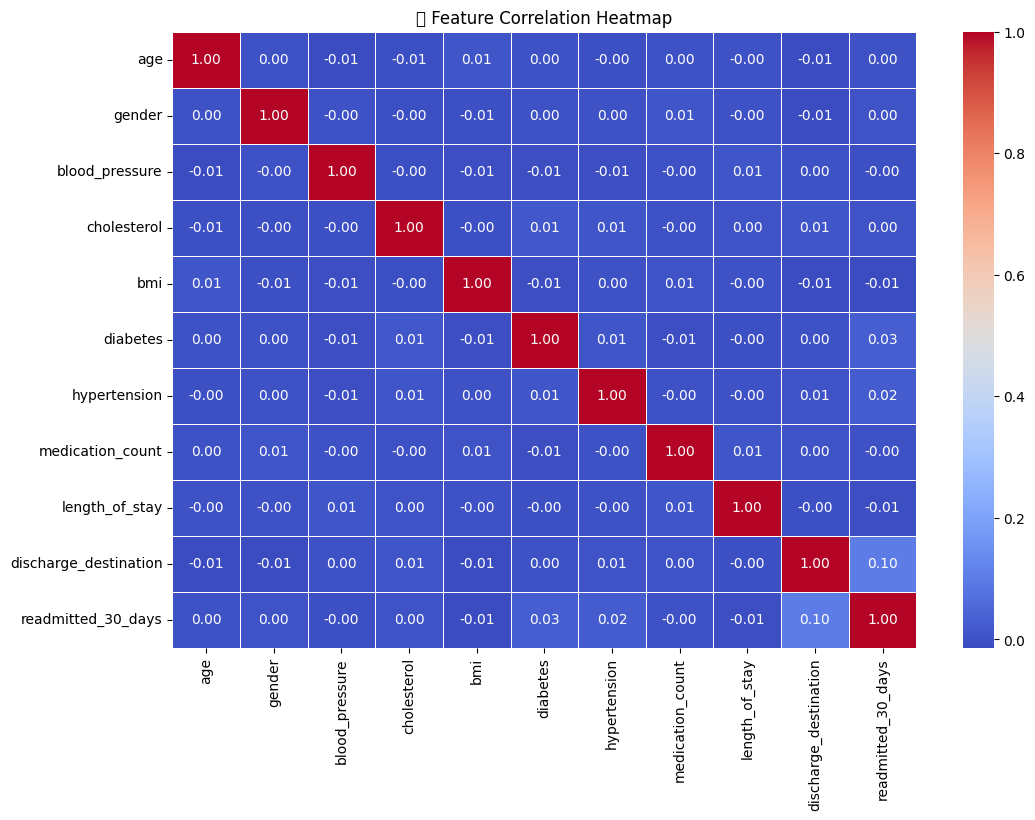

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


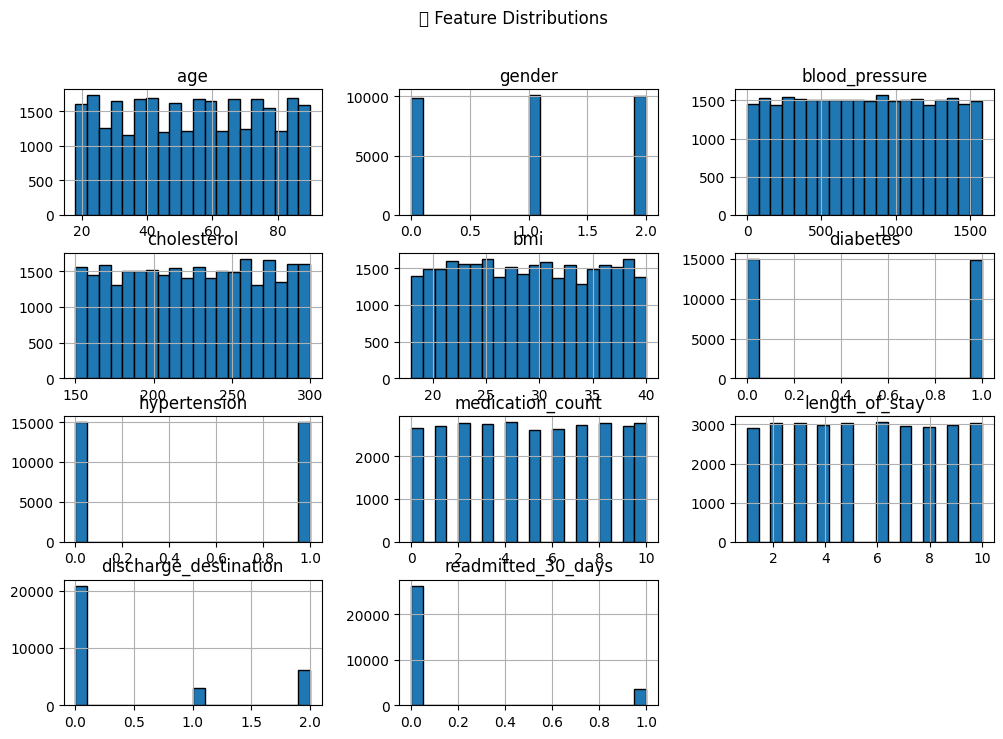

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load dataset
file_path = "/kaggle/input/hospital-readmission-predictionsynthetic-dataset/hospital_readmissions_30k.csv"
df = pd.read_csv(file_path)

# Drop non-essential identifier column
df.drop(columns=["patient_id"], inplace=True)

# Display dataset structure
print("\n🔍 Dataset Overview:")
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# Handle missing values
print("\n🛠 Missing Values:")
df.dropna(inplace=True)  # Remove rows with missing data

# Convert Yes/No categorical variables to numeric
binary_map = {"Yes": 1, "No": 0}
df["diabetes"] = df["diabetes"].map(binary_map)
df["hypertension"] = df["hypertension"].map(binary_map)
df["readmitted_30_days"] = df["readmitted_30_days"].map(binary_map)


categorical_cols = ["gender", "blood_pressure", "discharge_destination"]
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Generate correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("📊 Feature Correlation Heatmap")
plt.show()

# Feature distributions visualization
df.hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("📉 Feature Distributions")
plt.show()


# 🤖 2. Machine Learning Code Block
This will:

* Split data for training/testing

* Scale numerical features

* Train a Random Forest Classifier

* Predict readmission within 30 days

* Evaluate the model


🔍 Evaluating Logistic Regression
Accuracy: 0.8718
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.00      0.00      0.00       769

    accuracy                           0.87      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.76      0.87      0.81      6000

--------------------------------------------------

🔍 Evaluating Decision Tree
Accuracy: 0.7722


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

           0       0.87      0.86      0.87      5231
           1       0.14      0.15      0.14       769

    accuracy                           0.77      6000
   macro avg       0.51      0.51      0.51      6000
weighted avg       0.78      0.77      0.78      6000

--------------------------------------------------

🔍 Evaluating Random Forest
Accuracy: 0.8717
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.00      0.00      0.00       769

    accuracy                           0.87      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.76      0.87      0.81      6000

--------------------------------------------------

🔍 Evaluating SVM
Accuracy: 0.8718
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.00      0.00      0.00       769



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



🔍 Evaluating Gradient Boosting
Accuracy: 0.8713
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.20      0.00      0.00       769

    accuracy                           0.87      6000
   macro avg       0.54      0.50      0.47      6000
weighted avg       0.79      0.87      0.81      6000

--------------------------------------------------

🔍 Evaluating XGBoost
Accuracy: 0.8678
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      5231
           1       0.10      0.00      0.01       769

    accuracy                           0.87      6000
   macro avg       0.49      0.50      0.47      6000
weighted avg       0.77      0.87      0.81      6000

--------------------------------------------------

🔍 Evaluating KNN
Accuracy: 0.8627
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      5231
           1

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


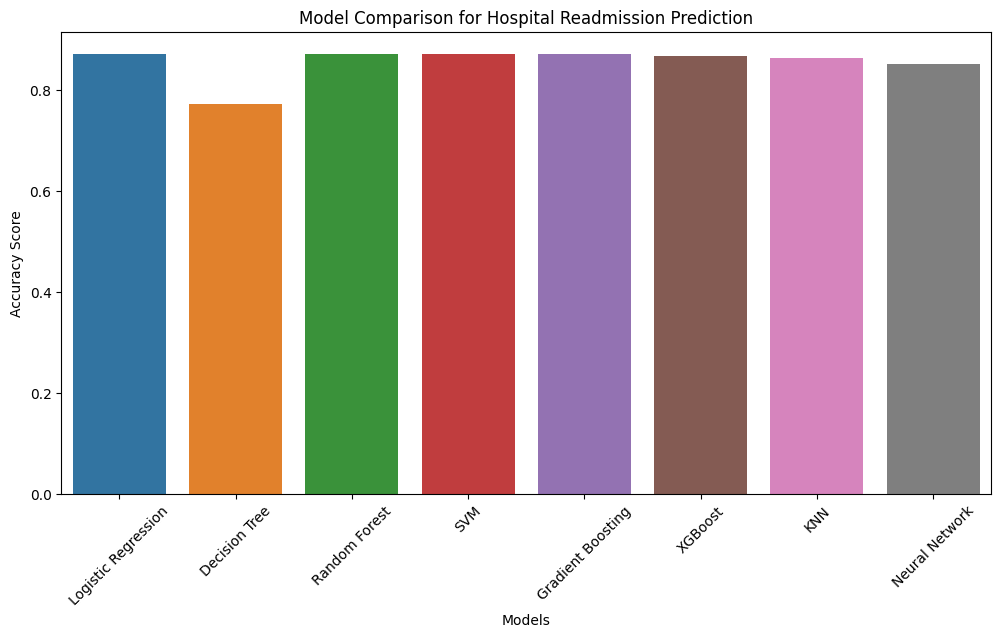

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# Define target variable
target = "readmitted_30_days"

# Prepare features and target
X = df.drop(columns=[target])
y = df[target]

# Ensure numeric columns only
X = X.select_dtypes(include=[np.number])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(50,50), max_iter=1000)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n🔍 Evaluating {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Visualizing model performance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Accuracy Score")
plt.title("Model Comparison for Hospital Readmission Prediction")
plt.show()
